In [42]:
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math
from torchmetrics.classification import MulticlassAccuracy, ConfusionMatrix
from timeit import default_timer as timer
from tqdm.notebook import tqdm
import sys
from mlxtend.plotting import plot_confusion_matrix

In [43]:
RANDOM_SEED = 42
BATCH_SIZE = 32

In [44]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "cpu"

In [45]:
train_data = datasets.FashionMNIST(
    root= "data",
    train=True,
    transform=ToTensor(),
    target_transform=None,
    download=True,
)

test_data = datasets.FashionMNIST(
    root= "data",
    train=False,
    transform=ToTensor(),
    target_transform=None,
    download=True,
)

In [46]:
train_data_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_data_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [47]:
class CNN_Model_2(nn.Module):
    def __init__(self, input_shape, output_features, hidden_neurons):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_neurons, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_neurons, out_channels=hidden_neurons, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_neurons, out_channels=hidden_neurons, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_neurons, out_channels=hidden_neurons, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_neurons*49, out_features=output_features),
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        # print(f"shape of conv block 1{x.shape}")
        x = self.conv_block_2(x)
        # print(f"shape of conv block 2{x.shape}")
        x = self.classifier_block(x)
        # print(f"shape of classifier block{x.shape}")
        return x

In [48]:
class_names = test_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [49]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
cnn_model = CNN_Model_2(input_shape=1, hidden_neurons=32, output_features=len(class_names)).to(device)

In [50]:
optimizer = torch.optim.AdamW(cnn_model.parameters(), lr=.001)
loss_fn = nn.CrossEntropyLoss()
acc_fn = MulticlassAccuracy(num_classes=len(class_names)).to(device)
confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))

In [51]:
def train_step(model: torch.nn.Module,
                optimizer: torch.optim.AdamW, 
                loss_fn: torch.nn.CrossEntropyLoss, 
                train_data_loader: torch.utils.data.DataLoader, 
                acc_fn: MulticlassAccuracy, 
                epoch, 
                device: torch.device = device):

    model.train()

    train_loss, train_acc = 0, 0

    pbar = tqdm(train_data_loader, desc=f"training step for the {epoch+1} epoch", leave=False)

    for X, y in pbar:

        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        train_logits = model(X)
        train_pred = torch.softmax(train_logits, dim=1).argmax(dim=1)

        train_loss_ = loss_fn(train_logits, y)
        train_loss_.backward()

        optimizer.step()

        train_loss_ = loss_fn(train_logits, y)
        train_loss += train_loss_.item()

        train_acc_ = acc_fn(train_pred, y)
        train_acc += train_acc_.item()

    train_acc /= len(train_data_loader)
    train_loss /= len(train_data_loader)

    pbar.set_postfix({"loss": f"{train_loss_.item():.4f}"})

    return train_loss, train_acc

In [52]:
def validation_step(model, 
              loss_fn: torch.nn.CrossEntropyLoss, 
              test_data_loader: torch.utils.data.DataLoader, 
              acc_fn: MulticlassAccuracy, 
              epoch, 
              device: torch.device=device):

    model.eval()
    test_acc, test_loss = 0, 0

    with torch.inference_mode():

        pbar = tqdm(test_data_loader, desc=f"testing step for the {epoch+1} epoch", leave=False)

        for X, y in pbar:

            X, y = X.to(device), y.to(device)

            test_logits = model(X) 
            test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

            test_loss_ = loss_fn(test_logits, y)
            test_loss += test_loss_.item()

            test_acc_ = acc_fn(test_preds, y)
            test_acc += test_acc_.item()

        test_acc /= len(test_data_loader)
        test_loss /= len(test_data_loader)

        pbar.set_postfix({"loss": f"{test_loss_.item():.4f}"})

    return test_loss, test_acc

In [53]:
def train_time(start: float,
               end: float,
               device: torch.device = None):
    total_time = end - start
    print(f"total training time {total_time:.3f} on the {device}")
    return total_time

In [54]:
torch.cuda.manual_seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

start_time = timer()
epochs = 4

epoch_pbar = tqdm(range(epochs), desc="Overall Progress")

for epoch in epoch_pbar:
    train_loss, train_acc = train_step(cnn_model, optimizer, loss_fn, train_data_loader, acc_fn, epoch, device)
    test_loss, test_acc = validation_step(cnn_model, loss_fn, test_data_loader, acc_fn, epoch, device)

    epoch_pbar.set_postfix({
            "train_loss": f"{train_loss:.4f}",
            "test_acc": f"{test_acc * 100:.2f}%"
        })

end_time = timer()

train_time(start=start_time, end=end_time, device=device)

Overall Progress:   0%|          | 0/4 [00:00<?, ?it/s]

training step for the 1 epoch:   0%|          | 0/1875 [00:00<?, ?it/s]

testing step for the 1 epoch:   0%|          | 0/313 [00:00<?, ?it/s]

training step for the 2 epoch:   0%|          | 0/1875 [00:00<?, ?it/s]

testing step for the 2 epoch:   0%|          | 0/313 [00:00<?, ?it/s]

...

testing step for the 3 epoch:   0%|          | 0/313 [00:00<?, ?it/s]

training step for the 4 epoch:   0%|          | 0/1875 [00:00<?, ?it/s]

testing step for the 4 epoch:   0%|          | 0/313 [00:00<?, ?it/s]

total training time 207.873 on the cuda


207.87317090000033

In [55]:
print(f"the train acc :{train_acc*100}% with a loss of {train_loss}")
print(f"the test acc :{test_acc*100}% with a loss of {test_loss}")

the train acc :91.61298350016276% with a loss of 0.2061223449885845
the test acc :90.65299502576882% with a loss of 0.23920222750296607


In [58]:
def eval_model(model: torch.nn.Module, 
              loss_fn: torch.nn.CrossEntropyLoss, 
              test_data_loader: torch.utils.data.DataLoader, 
              acc_fn: MulticlassAccuracy, 
              device: torch.device=device):

    model.eval()
    test_acc, test_loss = 0, 0
    test_preds = []

    with torch.inference_mode():

        pbar = tqdm(test_data_loader, desc=f"model evaluation", leave=False)

        for X, y in pbar:

            X, y = X.to(device), y.to(device)

            test_logits = model(X) 
            test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
            test_preds.append(test_pred.cpu())

            test_loss_ = loss_fn(test_logits, y)
            test_loss += test_loss_.item()

            test_acc_ = acc_fn(test_pred, y)
            test_acc += test_acc_.item()

        test_acc /= len(test_data_loader)
        test_loss /= len(test_data_loader)
        test_preds_tensor = torch.cat(test_preds)


        pbar.set_postfix({"loss": f"{test_loss_.item():.4f}"})

    return {
            "model_name": model.__class__.__name__,
            "model_loss": test_loss,
            "model_acc": test_acc
        }, test_preds_tensor

In [59]:
_ , test_preds_tensor = eval_model(cnn_model, loss_fn, test_data_loader, acc_fn*100, device)
test_preds_tensor[0:10]

model evaluation:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [61]:
test_data.targets[0:10]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

damn they match perfectly what a good job 

In [63]:
confmat_tensor = confmat(test_preds_tensor, test_data.targets)
confmat_tensor

tensor([[857,   0,  31,  17,   4,   1,  89,   0,   1,   0],
        [  1, 984,   0,  11,   2,   0,   2,   0,   0,   0],
        [  8,   1, 912,   5,  36,   0,  38,   0,   0,   0],
        [  9,   4,  20, 898,  39,   0,  30,   0,   0,   0],
        [  0,   1,  49,  16, 860,   0,  74,   0,   0,   0],
        [  0,   0,   0,   0,   0, 991,   0,   4,   0,   5],
        [105,   2,  67,  24,  69,   0, 730,   0,   3,   0],
        [  0,   0,   0,   0,   0,  18,   0, 959,   0,  23],
        [  2,   1,   3,   1,   5,   1,   6,   2, 979,   0],
        [  0,   0,   1,   0,   0,   3,   0,  16,   0, 980]])

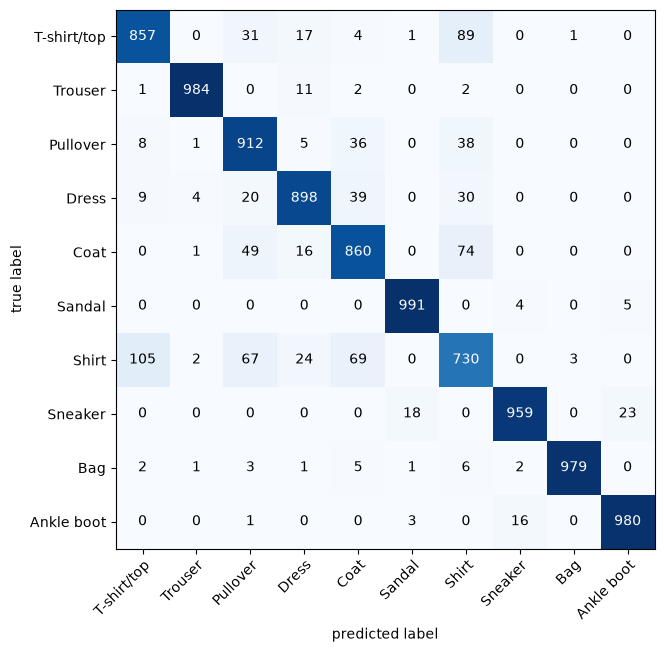

In [66]:
fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.numpy(), class_names=class_names, figsize=(11,7))
plt.show()

### saving the model for later use 

In [67]:
from pathlib import Path

MODELS_PATH = Path("models")                        # creating the folder path
MODELS_PATH.mkdir(exist_ok=True, parents=True)      # checking if the directory is ready if not create a new one
MODELS_SAVE_PATH = MODELS_PATH / "cnn_final_model.pth"  # preparing the save path for the model file using a (pth) extension

torch.save(cnn_model.state_dict(), MODELS_SAVE_PATH)

In [69]:
cnn_model_saved = CNN_Model_2(input_shape=1, hidden_neurons=32, output_features=len(class_names)).to(device)    # instantiating the model
cnn_model_saved.load_state_dict(torch.load(MODELS_SAVE_PATH, weights_only=True))
# torch.load only loads the state dict in case of saving the model state dict only so loading it into the already instantiated model is necessary

cnn_model_saved.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 0.1208,  0.1348, -0.2247],
                        [ 0.1840, -0.1502, -0.0505],
                        [-0.2708,  0.0732,  0.1796]]],
              
              
                      [[[-0.2813,  0.2021, -0.0289],
                        [ 0.1537,  0.0081,  0.0853],
                        [-0.0932,  0.1967, -0.0209]]],
              
              
                      [[[ 0.0281,  0.2899, -0.0020],
                        [-0.0734, -0.0694,  0.3462],
                        [-0.3925, -0.1555,  0.0212]]],
              
              
                      [[[-0.1804, -0.0269, -0.3038],
                        [ 0.3566, -0.3395,  0.3221],
                        [ 0.0862, -0.1498,  0.2528]]],
              
              
                      [[[-0.0055,  0.2189, -0.0637],
                        [-0.1051,  0.1412, -0.1300],
                        [ 0.1059,  0.3282,  0.1597]]],
              
              
      

In [70]:
_ , test_preds_tensor_saved = eval_model(cnn_model_saved, loss_fn, test_data_loader, acc_fn*100, device)
test_preds_tensor_saved[0:10]

model evaluation:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [71]:
print(test_preds_tensor_saved==test_data.targets)

tensor([True, True, True,  ..., True, True, True])


In [77]:
_

{'model_name': 'CNN_Model_2',
 'model_loss': 0.23920222750296607,
 'model_acc': 90.65299492979202}